In [1]:
import json
import pandas as pd

# Load NDJSON file using pandas (more efficient)
# Using chunks if the file is too large for memory
df = pd.read_json("/Users/shubhampareek/AML/DSPP/data/fox8_23_dataset.ndjson", lines=True)

# Set pandas options to see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', 50)

# Display a summary of the dataframe instead of the whole content
print("Original Dataframe Info:")
print(df.info())

# Flatten the nested data
# 1. Explode the user_tweets column so each tweet gets its own row
df_exploded = df.explode("user_tweets").reset_index(drop=True)

# 2. Normalize the user_tweets dictionaries into separate columns
# We only normalize the user_tweets column and join it back to user_id and label
tweets_normalized = pd.json_normalize(df_exploded["user_tweets"])




Original Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      2280 non-null   int64 
 1   label        2280 non-null   object
 2   dataset      2280 non-null   object
 3   user_tweets  2280 non-null   object
dtypes: int64(1), object(3)
memory usage: 71.4+ KB
None


In [2]:
# Display the flattened dataframe as a big table
# 3. Combine them back
# We drop the original 'user_tweets' column and join with the normalized columns
df_flat = pd.concat([df_exploded[["user_id", "label"]], tweets_normalized], axis=1)

print("\nFlattened Dataframe Info:")
print(df_flat.info())
print("\nFirst 5 rows of flattened data:")
print(df_flat.head())



Flattened Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368028 entries, 0 to 368027
Columns: 371 entries, user_id to retweeted_status.quoted_status.user.withheld_in_countries
dtypes: bool(18), float64(58), int64(10), object(285)
memory usage: 997.5+ MB
None

First 5 rows of flattened data:
    user_id  label contributors  truncated                                               text  is_quote_status  in_reply_to_status_id                  id  favorite_count                                             source  retweeted  coordinates in_reply_to_screen_name  in_reply_to_user_id  retweet_count              id_str  favorited  geo in_reply_to_user_id_str lang                      created_at in_reply_to_status_id_str  place entities.symbols                             entities.user_mentions                                  entities.hashtags                                      entities.urls  user.follow_request_sent  user.has_extended_profile  user.profile_use_background_i

cleaning the data
keeping the relevant rows

In [3]:
cols_needed = [
    "user_id",
    "label",
    "id",                      # tweet id
    "created_at",
    "retweeted",
    "retweeted_status.id",
    "retweeted_status.user.id"
]


In [4]:
# cleaning the data
import pandas as pd

df_clean = df_flat[cols_needed].copy()
df_clean.head()

,user_id,label,id,created_at,retweeted,retweeted_status.id,retweeted_status.user.id
0,16905397,human,986607535674322945,Wed Apr 18 14:09:01 +0000 2018,False,NaN,NaN
1,16905397,human,986605134649081858,Wed Apr 18 13:59:28 +0000 2018,False,NaN,NaN
2,16905397,human,986601549194579968,Wed Apr 18 13:45:14 +0000 2018,False,NaN,NaN
3,16905397,human,986523487807426560,Wed Apr 18 08:35:02 +0000 2018,False,NaN,NaN
4,16905397,human,986471574818689024,Wed Apr 18 05:08:45 +0000 2018,False,NaN,NaN


In [5]:
df_clean = df_clean.rename(columns={
    "retweeted_status.user.id": "retweeted_user_id",
    "retweeted_status.id": "retweeted_status_id"
})

In [6]:
df_clean.head()

,user_id,label,id,created_at,retweeted,retweeted_status_id,retweeted_user_id
0,16905397,human,986607535674322945,Wed Apr 18 14:09:01 +0000 2018,False,NaN,NaN
1,16905397,human,986605134649081858,Wed Apr 18 13:59:28 +0000 2018,False,NaN,NaN
2,16905397,human,986601549194579968,Wed Apr 18 13:45:14 +0000 2018,False,NaN,NaN
3,16905397,human,986523487807426560,Wed Apr 18 08:35:02 +0000 2018,False,NaN,NaN
4,16905397,human,986471574818689024,Wed Apr 18 05:08:45 +0000 2018,False,NaN,NaN


In [7]:
df_clean = df_clean[df_clean["retweeted_user_id"].notnull()]

basically creates a strcuture where user A retweets user B

In [8]:
df_clean["user_id"] = df_clean["user_id"].astype(int)
df_clean["retweeted_user_id"] = df_clean["retweeted_user_id"].astype(int)

print(df_clean.head())
print("Shape after cleaning:", df_clean.shape)

     user_id  label                  id                      created_at  retweeted  retweeted_status_id  retweeted_user_id
6   16905397  human  986343247449612288  Tue Apr 17 20:38:50 +0000 2018      False         9.863212e+17         1707949788
7   16905397  human  986342504583876609  Tue Apr 17 20:35:53 +0000 2018      False         9.861869e+17           19389942
8   16905397  human  986325437663105035  Tue Apr 17 19:28:04 +0000 2018      False         9.854526e+17         1707949788
9   16905397  human  986323344097243136  Tue Apr 17 19:19:44 +0000 2018      False         9.863230e+17         1707949788
10  16905397  human  986321504458690561  Tue Apr 17 19:12:26 +0000 2018      False         9.863214e+17         1707949788
Shape after cleaning: (131187, 7)


In [9]:
# removing self retweets, for the edge cases
df_clean = df_clean[df_clean["user_id"] != df_clean["retweeted_user_id"]]
print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (129928, 7)


In [10]:
print("Unique retweeters:", df_clean["user_id"].nunique())
print("Unique retweeted:", df_clean["retweeted_user_id"].nunique())
print("Total retweet edges:", len(df_clean))

Unique retweeters: 2214
Unique retweeted: 54431
Total retweet edges: 129928


Building graph to analyze the cluster of retweet

In [11]:
import networkx as nx
G = nx.DiGraph()

# Add edges
edges = list(zip(df_clean["user_id"], df_clean["retweeted_user_id"]))
G.add_edges_from(edges)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 55862
Number of edges: 94928


In [12]:
# Create mapping user_id -> label
label_map = df_clean[["user_id", "label"]].drop_duplicates()
label_dict = dict(zip(label_map["user_id"], label_map["label"]))

# Add node attributes
nx.set_node_attributes(G, label_dict, "label")


In [13]:
# Count bots and humans in graph
bot_nodes = [n for n, d in G.nodes(data=True) if d.get("label") == "bot"]
human_nodes = [n for n, d in G.nodes(data=True) if d.get("label") == "human"]

print("Bots in graph:", len(bot_nodes))
print("Humans in graph:", len(human_nodes))



Bots in graph: 1140
Humans in graph: 1074


In [14]:
print("Total nodes in graph:", G.number_of_nodes())

Total nodes in graph: 55862


Since the total number of node in the graph are around 55k , and bots in the graph are around 1140 and humans in graph 1074, it might amplify bots are targeting the external pages and there are two approaches
- Coordinate structure
- Amplification structure
Focusing on the cordinate strcuture and removing the edges to external pages from the graph DS

In [15]:
# Get all valid users in dataset
valid_users = set(df_clean["user_id"].unique()) # all fox8-user account, including bot and human

# Keep only internal retweets
df_clean_internal = df_clean[
    df_clean["retweeted_user_id"].isin(valid_users)   # retweeted_user_id ∈ valid_users
].copy()

print("Edges after filtering:", len(df_clean_internal))


Edges after filtering: 2475


Rebuilding the graph
DiGraph will store unique edges, so if someone retweets 5 times, only 1 is countes
2475 is unique retweet relationship
edges
[(A, B),
 (C, D),
 (E, F),
 ...]


In [16]:
G = nx.DiGraph()

edges = list(zip(
    df_clean_internal["user_id"],
    df_clean_internal["retweeted_user_id"]
))

G.add_edges_from(edges) # add nodes if they don't exist

# Add labels again
# label map from the full dataset (not df_clean_internal)
label_dict_full = dict(zip(
    df[["user_id", "label"]].drop_duplicates()["user_id"],
    df[["user_id", "label"]].drop_duplicates()["label"]
))

nx.set_node_attributes(G, label_dict_full, "label")



1227 nodes in graph :
Retweeted someone internally OR Were retweeted internally

appear in the graph.

All other accounts are isolated and therefore not added.

NetworkX only creates nodes that appear in edges.

In [17]:
# creating bot-bot and human-human graph from the previous graph
bot_nodes = [n for n, d in G.nodes(data=True) if d.get("label") == "bot"]
human_nodes = [n for n, d in G.nodes(data=True) if d.get("label") == "human"]
unknown_nodes = [n for n, d in G.nodes(data=True) if "label" not in d]

print("Bot nodes:", len(bot_nodes))
print("Human nodes:", len(human_nodes))
print("Unlabeled nodes:", len(unknown_nodes))
print("Total nodes:", G.number_of_nodes())



Bot nodes: 995
Human nodes: 232
Unlabeled nodes: 0
Total nodes: 1227


In [18]:
# g_bot will contain only bot->bot retweet edge and g_human will contain only human-> human retweet
G_bot = G.subgraph(bot_nodes).copy()
G_human = G.subgraph(human_nodes).copy()

print("Bot graph nodes:", G_bot.number_of_nodes(), "edges:", G_bot.number_of_edges())
print("Human graph nodes:", G_human.number_of_nodes(), "edges:", G_human.number_of_edges())



Bot graph nodes: 995 edges: 1619
Human graph nodes: 232 edges: 284


In [19]:

def core_metrics(G):
    N = G.number_of_nodes()
    E = G.number_of_edges()

    # density for directed graph
    density = E / (N * (N - 1)) if N > 1 else 0.0

    # reciprocity (can be None if no edges)
    reciprocity = nx.reciprocity(G)
    reciprocity = 0.0 if reciprocity is None else float(reciprocity)

    # largest weakly connected component fraction
    if N > 0:
        lcc = max(nx.weakly_connected_components(G), key=len)
        lcc_frac = len(lcc) / N
    else:
        lcc_frac = 0.0

    # clustering on undirected projection
    clustering = nx.average_clustering(G.to_undirected()) if N > 1 else 0.0

    return {
        "N": N,
        "E": E,
        "density": density,
        "reciprocity": reciprocity,
        "lcc_frac": lcc_frac,
        "avg_clustering": clustering
    }

bot_stats = core_metrics(G_bot)
human_stats = core_metrics(G_human)

print("BOT metrics:", bot_stats)
print("HUMAN metrics:", human_stats)


BOT metrics: {'N': 995, 'E': 1619, 'density': 0.001636957422929537, 'reciprocity': 0.0012353304508956147, 'lcc_frac': 0.9909547738693467, 'avg_clustering': 0.017549936679407564}
HUMAN metrics: {'N': 232, 'E': 284, 'density': 0.005299298402746679, 'reciprocity': 0.02112676056338028, 'lcc_frac': 0.6724137931034483, 'avg_clustering': 0.04789952324973877}


In-Degree Distribution - how many times a user has retweeted
Out Degree Distribution - how many different account a user interact
and Gini-Index - If equal to 1,  few nodes domainate and if equal to 0, evenly distributed

comparison with the paper

In [20]:
import numpy as np
bot_in_deg = np.array([d for n, d in G_bot.in_degree()])
human_in_deg = np.array([d for n, d in G_human.in_degree()])

print("Bot max in-degree:", bot_in_deg.max())
print("Human max in-degree:", human_in_deg.max())

print("Bot mean in-degree:", bot_in_deg.mean())
print("Human mean in-degree:", human_in_deg.mean())


Bot max in-degree: 10
Human max in-degree: 64
Bot mean in-degree: 1.6271356783919597
Human mean in-degree: 1.2241379310344827


In [21]:
bot_out_deg = np.array([d for n, d in G_bot.out_degree()])
human_out_deg = np.array([d for n, d in G_human.out_degree()])

print("Bot max out-degree:", bot_out_deg.max())
print("Human max out-degree:", human_out_deg.max())

print("Bot mean out-degree:", bot_out_deg.mean())
print("Human mean out-degree:", human_out_deg.mean())


Bot max out-degree: 8
Human max out-degree: 5
Bot mean out-degree: 1.6271356783919597
Human mean out-degree: 1.2241379310344827


In [22]:
def gini(x):
    x = np.array(x).astype(float)
    x = x[x >= 0]
    if np.amin(x) < 0:
        x -= np.amin(x)
    x += 1e-9
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n+1)
    return ((np.sum((2 * index - n - 1) * x)) / (n * np.sum(x)))

bot_gini_in = gini(bot_in_deg)
human_gini_in = gini(human_in_deg)

print("Bot Gini (in-degree):", bot_gini_in)
print("Human Gini (in-degree):", human_gini_in)


Bot Gini (in-degree): 0.5161148543762873
Human Gini (in-degree): 0.9171321022133967


The result might not be ideal because of the following reaosn
- the graph is restricted to internal bot -> bot and human -> human interaction
- but in the paper, the interaction is captured among the bots amplyifing exteral crypto accounts and those outbound connection nearly 53k are removed
- Building external grapp

In [23]:
G_full = nx.DiGraph()

edges_full = list(zip(
    df_clean["user_id"],
    df_clean["retweeted_user_id"]
))

G_full.add_edges_from(edges_full)

print("Total nodes (full):", G_full.number_of_nodes())
print("Total edges (full):", G_full.number_of_edges())


Total nodes (full): 55862
Total edges (full): 94928


In [24]:
# attaching labels only to the dataset user
# external nodes will not have any labels
label_dict_full = dict(zip(
    df[["user_id", "label"]].drop_duplicates()["user_id"],
    df[["user_id", "label"]].drop_duplicates()["label"]
))

nx.set_node_attributes(G_full, label_dict_full, "label")

In [25]:
# extracting retweet target of human and bots
bot_targets = []
human_targets = []

for u, v in G_full.edges():
    label = G_full.nodes[u].get("label")
    if label == "bot":
        bot_targets.append(v)
    elif label == "human":
        human_targets.append(v)

print("Total bot retweets:", len(bot_targets))
print("Total human retweets:", len(human_targets))


Total bot retweets: 38966
Total human retweets: 55962


 **Retweet target for bots and humans
for bots: retweeted target
for humans: retweeted target**

In [26]:
# measure target concentration i.e convert target into frequency distribution
from collections import Counter

bot_target_counts = Counter(bot_targets)
human_target_counts = Counter(human_targets)

print("Unique bot targets:", len(bot_target_counts))
print("Unique human targets:", len(human_target_counts))


Unique bot targets: 12372
Unique human targets: 42299


In [27]:
# Gini coefficient of target distribution
bot_gini_targets = gini(list(bot_target_counts.values()))
human_gini_targets = gini(list(human_target_counts.values()))

print("Bot Gini (target concentration):", bot_gini_targets)
print("Human Gini (target concentration):", human_gini_targets)

Bot Gini (target concentration): 0.6347959817515273
Human Gini (target concentration): 0.22877918532333869


# result interpretation
Basic counts:
Bots:
38,966 retweets, 12,372 unique targets
Humans:
55,962 retweets, 42,299 unique targets

Already this tells us something: Bots retweet far fewer unique accounts relative to their total retweets.

Gini Coeffiecent
Bot Gini (target concentration): 0.635
Human Gini (target concentration): 0.229
This is a very large difference.
Interpretation: Bots retweet a highly concentrated set of accounts. Humans retweet broadly and evenly.

This is strong structural evidence of coordinated amplification.

This supports the hypothesis: Bots form amplification networks targeting specific accounts. This aligns with the fox8 paper 2307.16336v1,which observed bots amplifying cryptocurrency-related accounts and websites.

In [28]:
# proportion of retweets going to top 1% of targets
def top_fraction(counter, fraction=0.01):
    total = sum(counter.values())
    sorted_counts = sorted(counter.values(), reverse=True)
    k = int(len(sorted_counts) * fraction)
    return sum(sorted_counts[:k]) / total

bot_top1 = top_fraction(bot_target_counts, 0.01)
human_top1 = top_fraction(human_target_counts, 0.01)

print("Bot % retweets to top 1% targets:", bot_top1)
print("Human % retweets to top 1% targets:", human_top1)


Bot % retweets to top 1% targets: 0.4842426730996253
Human % retweets to top 1% targets: 0.10296272470605053


In [29]:
print("bot_target_counts" in globals(), "human_target_counts" in globals())


True True


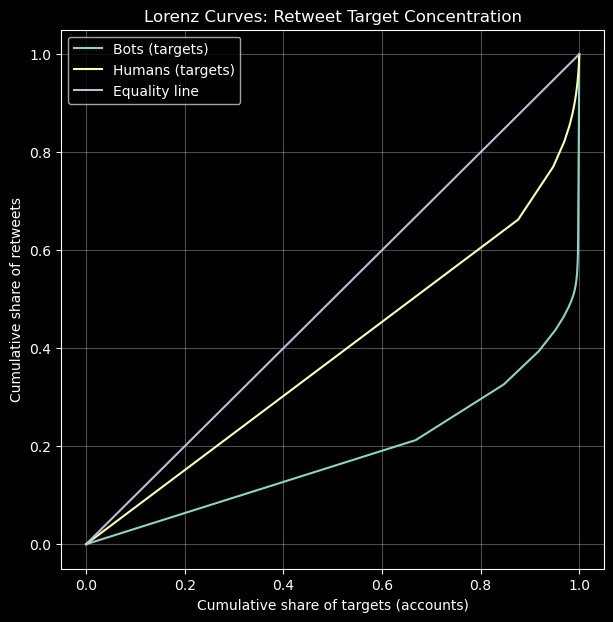

In [30]:
import matplotlib.pyplot as plt

# --- Lorenz curve helper ---
def lorenz_curve(counts):
    x = np.array(counts, dtype=float)
    x = np.sort(x)
    cum = np.cumsum(x)
    cum_share = np.insert(cum / cum[-1], 0, 0.0)  # start at 0
    pop_share = np.linspace(0.0, 1.0, len(cum_share))
    return pop_share, cum_share

bot_p, bot_l = lorenz_curve(list(bot_target_counts.values()))
hum_p, hum_l = lorenz_curve(list(human_target_counts.values()))

# --- Plot (no manual colors) ---
plt.figure(figsize=(7, 7))
plt.plot(bot_p, bot_l, label="Bots (targets)")
plt.plot(hum_p, hum_l, label="Humans (targets)")
plt.plot([0, 1], [0, 1], label="Equality line")
plt.xlabel("Cumulative share of targets (accounts)")
plt.ylabel("Cumulative share of retweets")
plt.title("Lorenz Curves: Retweet Target Concentration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**What this visualization shows:**
- **Diagonal line (k--)**: Perfect equality - every target gets equal retweets
- **Bot curve (blue)**: Strongly bends away from diagonal, showing high concentration (Gini=0.635)
- **Human curve (orange)**: Much closer to diagonal, showing more even distribution (Gini=0.229)

The large gap between bot and human curves visually demonstrates that bots coordinate to amplify specific accounts, while humans retweet more diversely.
Please add this code as a new cell in your notebook to generate the Lorenz curve visualization.

In [31]:
import pandas as pd

TOP_N = 10  # change if you want 10/50

top_bot = bot_target_counts.most_common(TOP_N)
top_human = human_target_counts.most_common(TOP_N)

top_bot_df = pd.DataFrame(top_bot, columns=["target_user_id", "retweets_from_bots"])
top_human_df = pd.DataFrame(top_human, columns=["target_user_id", "retweets_from_humans"])

print("Top targets amplified by BOTS:")
display(top_bot_df)

print("\nTop targets amplified by HUMANS:")
display(top_human_df)

Top targets amplified by BOTS:


,target_user_id,retweets_from_bots
0,1502160779339976704,882
1,910110294625492992,592
2,1368376334594961408,584
3,2872584449,582
4,1253392898638450688,578
5,1387497871751196672,571
6,1373422240969027584,562
7,295218901,559
8,902926941413453824,558
9,902282851499917312,557



Top targets amplified by HUMANS:


,target_user_id,retweets_from_humans
0,813286,73
1,25073877,64
2,32871086,48
3,14247236,48
4,30354991,47
5,49698134,42
6,939091,41
7,21059255,40
8,1917731,40
9,28785486,39


In [32]:
target_id = int(top_bot_df.loc[0, "target_user_id"])
print("Internal target?" , (df["user_id"] == target_id).any())




Internal target? False


In [47]:
# Investigate the #1 bot target: 1502160779339976704
target_id = 30354991

# Find all retweets pointing to this target
target_retweets = df_clean[df_clean['retweeted_user_id'] == target_id].copy()

print(f"=== Investigating Target: {target_id} ===")
print(f"Total retweets to this target: {len(target_retweets)}")
print(f"\nBreakdown by label:")
print(target_retweets['label'].value_counts())

# Who are the retweeters?
print(f"\nNumber of unique users retweeting this target: {target_retweets['user_id'].nunique()}")

# Time analysis
target_retweets['created_at_dt'] = pd.to_datetime(target_retweets['created_at'])
print(f"\nTime range:")
print(f"First retweet: {target_retweets['created_at_dt'].min()}")
print(f"Last retweet: {target_retweets['created_at_dt'].max()}")

# Show sample of bot accounts retweeting this target
bot_retweeters = target_retweets[target_retweets['label'] == 'bot']['user_id'].unique()[:10]
print(f"\nSample bot accounts retweeting target {target_id}:")
print(bot_retweeters)

# Now let's find the actual tweet content from df_flat
# The target_id is the retweeted_user_id, so we need to look in the flattened data
# for tweets that reference this user

print("\n=== Looking for tweet content about this target ===")

# Check if this target_id exists as a user in our dataset
if target_id in df_flat['user_id'].values:
    print(f"\nTarget {target_id} IS in our dataset as a user")
    target_tweets = df_flat[df_flat['user_id'] == target_id]
    print(f"Number of tweets from this user: {len(target_tweets)}")
    if len(target_tweets) > 0:
        # Show first tweet
        print("\nSample tweet from this user:")
        print(f"Text: {target_tweets.iloc[0]['text'][:200]}...")
        print(f"Created: {target_tweets.iloc[0]['created_at']}")
else:
    print(f"\nTarget {target_id} is EXTERNAL (not in our dataset)")
    print("This is an external account being amplified by bots in the dataset")

# Check if target is in the retweeted_status columns
if 'retweeted_status.user.id' in df_flat.columns:
    retweeted_status_matches = df_flat[df_flat['retweeted_status.user.id'] == target_id]
    if len(retweeted_status_matches) > 0:
        print(f"\nFound {len(retweeted_status_matches)} retweet records pointing to this user")
        print("\nSample retweet record:")
        sample = retweeted_status_matches.iloc[0]

        # Extract relevant info
        if 'retweeted_status.text' in df_flat.columns and pd.notna(sample.get('retweeted_status.text')):
            print(f"Original tweet text: {sample['retweeted_status.text'][:200]}...")

        if 'retweeted_status.user.screen_name' in df_flat.columns:
            print(f"Target screen name: @{sample['retweeted_status.user.screen_name']}")

        if 'retweeted_status.created_at' in df_flat.columns:
            print(f"Original tweet date: {sample['retweeted_status.created_at']}")


=== Investigating Target: 30354991 ===
Total retweets to this target: 78

Breakdown by label:
label
human    78
Name: count, dtype: int64

Number of unique users retweeting this target: 47

Time range:
First retweet: 2017-11-25 17:41:54+00:00
Last retweet: 2020-07-31 01:28:09+00:00

Sample bot accounts retweeting target 30354991:
[]

=== Looking for tweet content about this target ===

Target 30354991 is EXTERNAL (not in our dataset)
This is an external account being amplified by bots in the dataset

Found 78 retweet records pointing to this user

Sample retweet record:
Original tweet text: Yesterday I sent a letter with some of my colleagues calling on the Justice Department to protect the Special Couns… https://t.co/b9wQpJ710a...
Target screen name: @KamalaHarris
Original tweet date: Thu Mar 29 00:17:00 +0000 2018


/var/folders/zk/q5w3vg5d5y7_xzpvhgf6502h0000gn/T/ipykernel_59166/1819368408.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  target_retweets['created_at_dt'] = pd.to_datetime(target_retweets['created_at'])


In [34]:
from scipy.stats import entropy


# Compute entropy of target distribution
def compute_entropy(counter):
    """
    Compute Shannon entropy of a distribution.
    Higher entropy = more uniform/diverse
    Lower entropy = more concentrated
    """
    counts = np.array(list(counter.values()))
    # Normalize to get probability distribution
    probs = counts / counts.sum()
    # Compute Shannon entropy (in bits)
    return entropy(probs, base=2)


def max_entropy(n):
    """
    Maximum possible entropy for n unique targets (uniform distribution)
    """
    return np.log2(n)


# Calculate entropies
bot_entropy = compute_entropy(bot_target_counts)
human_entropy = compute_entropy(human_target_counts)

# Maximum possible entropy (uniform distribution)
bot_max_entropy = max_entropy(len(bot_target_counts))
human_max_entropy = max_entropy(len(human_target_counts))

# Normalized entropy (0 to 1 scale)
bot_norm_entropy = bot_entropy / bot_max_entropy if bot_max_entropy > 0 else 0
human_norm_entropy = human_entropy / human_max_entropy if human_max_entropy > 0 else 0

print("=== ENTROPY ANALYSIS ===\n")
print("BOT RETWEET TARGETS:")
print(f"  Shannon Entropy: {bot_entropy:.4f} bits")
print(f"  Max Possible Entropy: {bot_max_entropy:.4f} bits")
print(f"  Normalized Entropy: {bot_norm_entropy:.4f} (0=concentrated, 1=uniform)")
print(f"  Unique targets: {len(bot_target_counts)}")

print("\nHUMAN RETWEET TARGETS:")
print(f"  Shannon Entropy: {human_entropy:.4f} bits")
print(f"  Max Possible Entropy: {human_max_entropy:.4f} bits")
print(f"  Normalized Entropy: {human_norm_entropy:.4f} (0=concentrated, 1=uniform)")
print(f"  Unique targets: {len(human_target_counts)}")

print("\n=== COMPARISON ===")
print(f"Entropy ratio (Bot/Human): {bot_entropy / human_entropy:.4f}")
print(f"Normalized entropy ratio: {bot_norm_entropy / human_norm_entropy:.4f}")

print("\n=== INTERPRETATION ===")
if bot_norm_entropy < human_norm_entropy:
    diff_pct = ((human_norm_entropy - bot_norm_entropy) / human_norm_entropy) * 100
    print(f"✓ Bots have {diff_pct:.1f}% LOWER normalized entropy than humans")
    print("  → Bot retweets are MORE CONCENTRATED on specific targets")
    print("  → Consistent with coordinated amplification behavior")
else:
    print("✗ Unexpected: Bots have higher entropy than humans")

print("\n=== METRICS SUMMARY ===")
print(f"{'Metric':<30} {'Bots':>12} {'Humans':>12} {'Interpretation':>20}")
print("-" * 80)
print(f"{'Gini Coefficient':<30} {bot_gini_targets:>12.4f} {human_gini_targets:>12.4f} {'Higher=Concentrated':>20}")
print(f"{'Normalized Entropy':<30} {bot_norm_entropy:>12.4f} {human_norm_entropy:>12.4f} {'Lower=Concentrated':>20}")
print(f"{'Unique Targets':<30} {len(bot_target_counts):>12} {len(human_target_counts):>12} {'Fewer=Concentrated':>20}")
print(f"{'Total Retweets':<30} {len(bot_targets):>12} {len(human_targets):>12} {'-':>20}")
print(f"{'Top 1% Target Share':<30} {bot_top1:>12.2%} {human_top1:>12.2%} {'Higher=Concentrated':>20}")

print("\n✓ All metrics agree: Bots show concentrated targeting, Humans show diverse behavior")


=== ENTROPY ANALYSIS ===

BOT RETWEET TARGETS:
  Shannon Entropy: 10.6588 bits
  Max Possible Entropy: 13.5948 bits
  Normalized Entropy: 0.7840 (0=concentrated, 1=uniform)
  Unique targets: 12372

HUMAN RETWEET TARGETS:
  Shannon Entropy: 14.9977 bits
  Max Possible Entropy: 15.3683 bits
  Normalized Entropy: 0.9759 (0=concentrated, 1=uniform)
  Unique targets: 42299

=== COMPARISON ===
Entropy ratio (Bot/Human): 0.7107
Normalized entropy ratio: 0.8034

=== INTERPRETATION ===
✓ Bots have 19.7% LOWER normalized entropy than humans
  → Bot retweets are MORE CONCENTRATED on specific targets
  → Consistent with coordinated amplification behavior

=== METRICS SUMMARY ===
Metric                                 Bots       Humans       Interpretation
--------------------------------------------------------------------------------
Gini Coefficient                     0.6348       0.2288  Higher=Concentrated
Normalized Entropy                   0.7840       0.9759   Lower=Concentrated
Unique Ta

=== Velocity Sanity Check ===
        count  mean   std   min   25%   50%   75%    max
label                                                   
bot    1140.0  0.20  0.71  0.01  0.03  0.04  0.05   7.97
human  1139.0  5.53  8.94  0.00  0.62  2.09  6.59  88.03
Null velocities: 0


/var/folders/zk/q5w3vg5d5y7_xzpvhgf6502h0000gn/T/ipykernel_59166/3941737489.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=['Bots', 'Humans'], patch_artist=True,


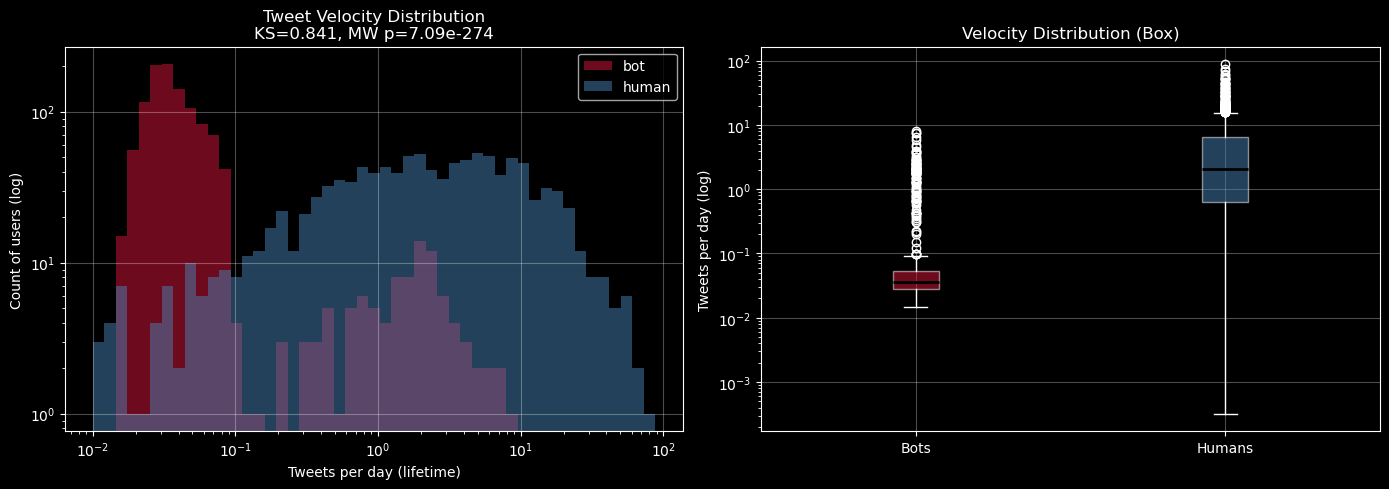


=== Hour-of-Day Flatness (std of hourly proportion) ===
Bot std:   0.00200  (lower = flatter = more uniform)
Human std: 0.01377

Chi-square vs uniform (bot):   chi2=330.0,   p=3.81e-56
Chi-square vs uniform (human): chi2=22845.9, p=0.00e+00
(Non-significant p = activity is uniformly spread = more bot-like)


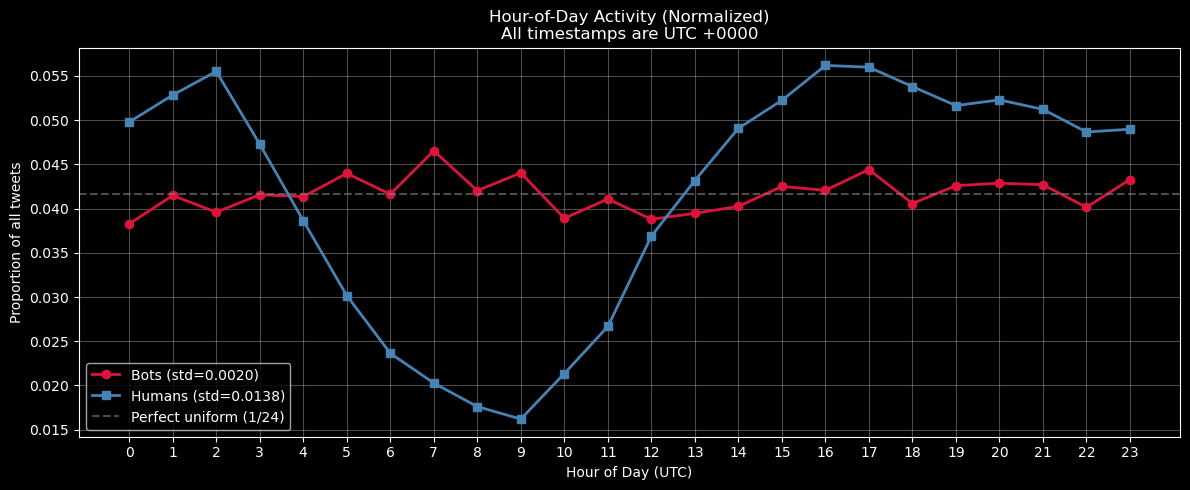

=== Engagement Received Fix Verification ===
         sent                                            received                                      
        count  mean   std  min   25%   50%    75%    max    count mean   std  min  25%  50%  75%    max
label                                                                                                  
bot    1140.0  44.0  17.0  1.0  33.0  43.0   56.0  193.0   1140.0  1.6   1.8  0.0  0.0  1.0  2.0   11.0
human  1139.0  71.1  57.1  0.0  20.0  60.0  115.0  199.0   1139.0  1.8  11.2  0.0  0.0  0.0  0.0  295.0

Bots with received > 0:   723
Humans with received > 0: 242

=== Engagement Asymmetry Ratio (1=pure sender, 0.5=balanced) ===
        count   mean    std    min    25%    50%  75%  max
label                                                     
bot    1140.0  0.965  0.044  0.333  0.946  0.976  1.0  1.0
human  1139.0  0.925  0.233  0.000  0.993  1.000  1.0  1.0


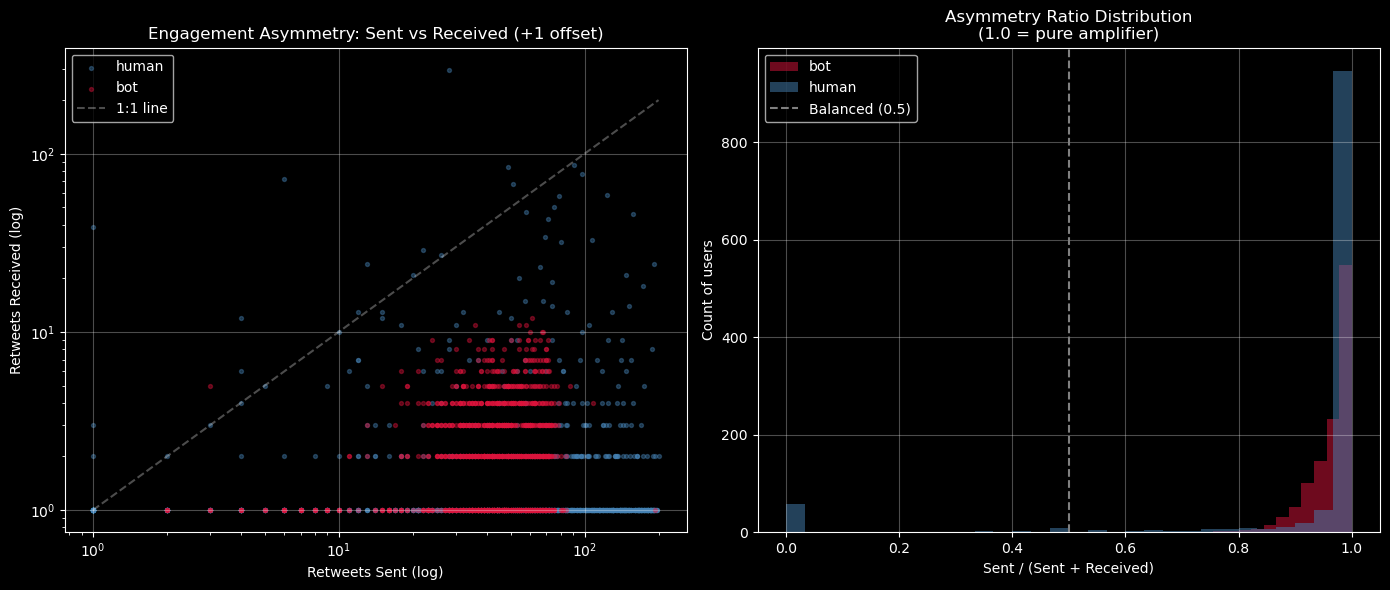

/var/folders/zk/q5w3vg5d5y7_xzpvhgf6502h0000gn/T/ipykernel_59166/3941737489.py:221: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  retweets['hour_bucket'] = retweets['created_at'].dt.floor('1H')



=== Synchrony Score within each group's active window ===
Bot CV:   0.959  (n_hours=1707)
Human CV: 1.183  (n_hours=18045)


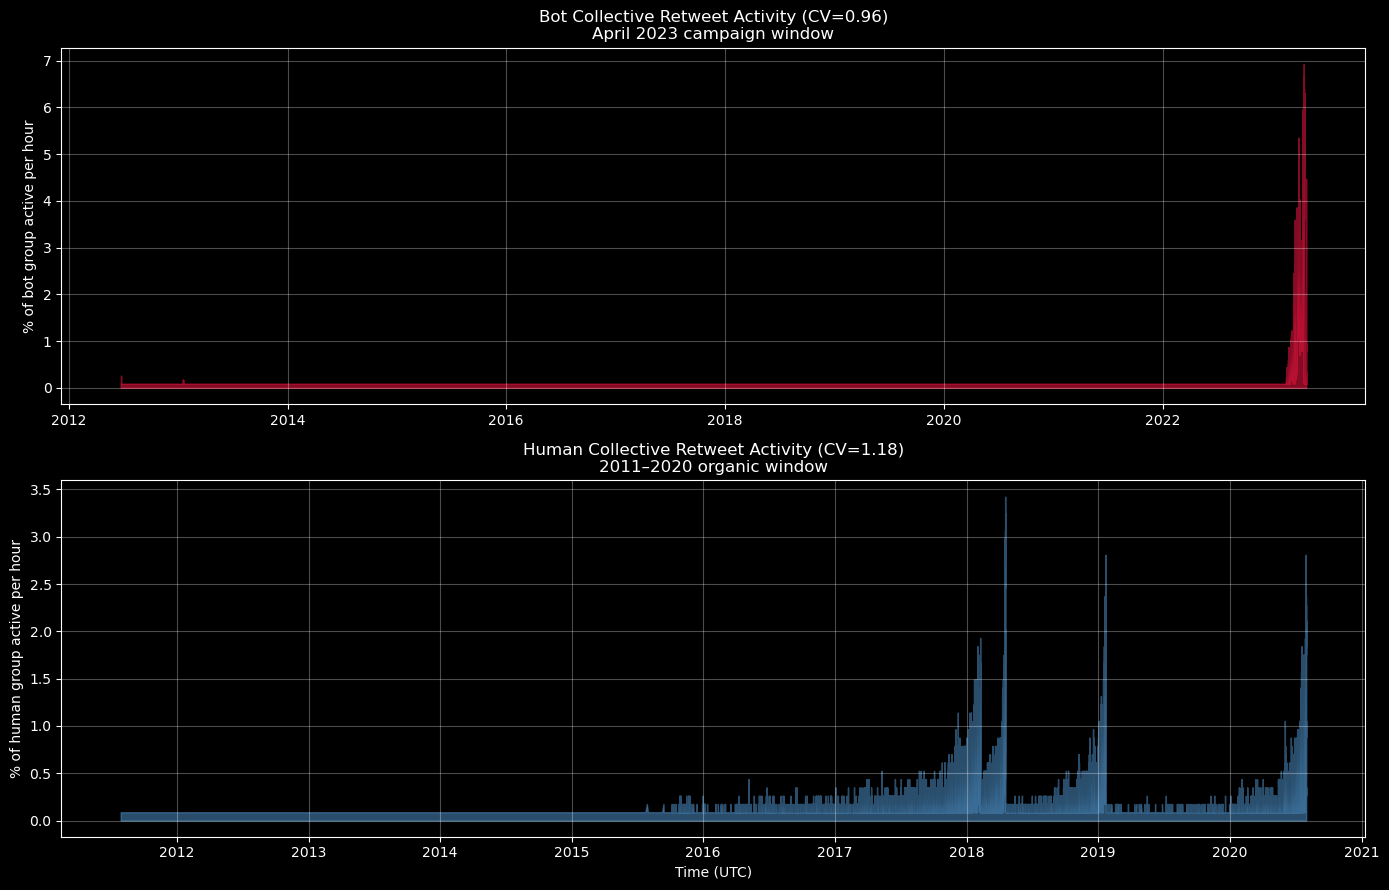


=== Peak Coordination (10-min windows, within own active period) ===
Max bot users in any 10-min window: 25
Top 3 windows:
tenmin_bucket
2023-04-17 23:10:00+00:00    25
2023-04-18 01:30:00+00:00    24
2023-04-17 17:50:00+00:00    23
Name: bot, dtype: int64

Max human users in any 10-min window: 18
Top 3 windows:
tenmin_bucket
2018-04-18 01:10:00+00:00    18
2018-04-17 22:40:00+00:00    16
2018-04-18 00:10:00+00:00    16
Name: human, dtype: int64



In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

TWITTER_FMT = '%a %b %d %H:%M:%S %z %Y'
REF_DATE    = pd.Timestamp('2023-04-25', tz='UTC')

# ── Parse timestamps properly ──────────────────────────────────────────────
df_flat['created_at'] = pd.to_datetime(
    df_flat['created_at'], format=TWITTER_FMT, utc=True
)

# ═══════════════════════════════════════════════════════════════════════════
# 1. TWEET VELOCITY
# Uses: user.created_at (account age) + user.statuses_count (lifetime tweets)
# ═══════════════════════════════════════════════════════════════════════════
user_profile = df_flat.groupby(['user_id', 'label']).agg(
    statuses_count=('user.statuses_count', 'first'),
    account_created=('user.created_at', 'first')
).reset_index()

# Parse with explicit format — same Twitter format as created_at
user_profile['account_created'] = pd.to_datetime(
    user_profile['account_created'], format=TWITTER_FMT, utc=True
)

user_profile['account_age_days'] = (
    REF_DATE - user_profile['account_created']
).dt.total_seconds() / 86400

user_profile['velocity'] = (
    user_profile['statuses_count'] / user_profile['account_age_days'].clip(lower=1)
)

# Sanity check before plotting
print("=== Velocity Sanity Check ===")
print(user_profile.groupby('label')['velocity'].describe().round(2))
null_velocity = user_profile['velocity'].isna().sum()
print(f"Null velocities: {null_velocity}")

# Statistical test
bots   = user_profile[user_profile['label'] == 'bot']['velocity'].dropna()
humans = user_profile[user_profile['label'] == 'human']['velocity'].dropna()
mw_stat, mw_p = stats.mannwhitneyu(bots, humans, alternative='two-sided')
ks_stat, ks_p = stats.ks_2samp(bots, humans)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
vmin = user_profile['velocity'].replace(0, np.nan).min()
vmax = user_profile['velocity'].max()
bins = np.logspace(np.log10(max(vmin, 0.01)), np.log10(vmax), 50)

for label, color in [('bot', 'crimson'), ('human', 'steelblue')]:
    subset = user_profile[user_profile['label'] == label]
    axes[0].hist(subset['velocity'], bins=bins, alpha=0.5, label=label,
                 color=color, log=True)

axes[0].set_xscale('log')
axes[0].set_title(f'Tweet Velocity Distribution\nKS={ks_stat:.3f}, MW p={mw_p:.2e}')
axes[0].set_xlabel('Tweets per day (lifetime)')
axes[0].set_ylabel('Count of users (log)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot for cleaner comparison
data_to_plot = [bots, humans]
bp = axes[1].boxplot(data_to_plot, labels=['Bots', 'Humans'], patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('crimson')
bp['boxes'][1].set_facecolor('steelblue')
for patch in bp['boxes']:
    patch.set_alpha(0.5)
axes[1].set_yscale('log')
axes[1].set_title('Velocity Distribution (Box)')
axes[1].set_ylabel('Tweets per day (log)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# 2. HOUR-OF-DAY ACTIVITY
# Uses: created_at (tweet timestamp) — all times are +0000 so UTC is correct
# NOTE: Valid comparison even without temporal overlap — hour pattern is
#       structural behavior, not tied to the specific year
# ═══════════════════════════════════════════════════════════════════════════
df_flat['hour'] = df_flat['created_at'].dt.hour

hour_dist = df_flat.groupby(['label', 'hour']).size().unstack(level=0)
hour_dist_pct = hour_dist.div(hour_dist.sum(axis=0), axis=1)

# Flatness score: std of hourly proportions (lower = flatter = more bot-like)
bot_flatness   = hour_dist_pct['bot'].std()
human_flatness = hour_dist_pct['human'].std()

print(f"\n=== Hour-of-Day Flatness (std of hourly proportion) ===")
print(f"Bot std:   {bot_flatness:.5f}  (lower = flatter = more uniform)")
print(f"Human std: {human_flatness:.5f}")

# Chi-square test: is the hourly distribution uniform?
bot_counts   = df_flat[df_flat['label'] == 'bot']['hour'].value_counts().sort_index()
human_counts = df_flat[df_flat['label'] == 'human']['hour'].value_counts().sort_index()
expected_uniform = np.full(24, bot_counts.sum() / 24)
chi2_bot,   p_bot   = stats.chisquare(bot_counts,   f_exp=expected_uniform)
chi2_human, p_human = stats.chisquare(human_counts, f_exp=np.full(24, human_counts.sum() / 24))
print(f"\nChi-square vs uniform (bot):   chi2={chi2_bot:.1f},   p={p_bot:.2e}")
print(f"Chi-square vs uniform (human): chi2={chi2_human:.1f}, p={p_human:.2e}")
print("(Non-significant p = activity is uniformly spread = more bot-like)")

plt.figure(figsize=(12, 5))
plt.plot(hour_dist_pct.index, hour_dist_pct['bot'],   label=f'Bots (std={bot_flatness:.4f})',
         marker='o', color='crimson', linewidth=2)
plt.plot(hour_dist_pct.index, hour_dist_pct['human'], label=f'Humans (std={human_flatness:.4f})',
         marker='s', color='steelblue', linewidth=2)
plt.axhline(1/24, color='grey', linestyle='--', alpha=0.6, label='Perfect uniform (1/24)')
plt.title('Hour-of-Day Activity (Normalized)\nAll timestamps are UTC +0000')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Proportion of all tweets')
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# 3. ENGAGEMENT ASYMMETRY
# Uses: retweeted_status.id (sent), retweeted_status.user.id (received)
# ═══════════════════════════════════════════════════════════════════════════
retweets_sent = (
    df_flat[df_flat['retweeted_status.id'].notnull()]
    .groupby('user_id').size()
    .reset_index(name='sent')
)

# Fixed: filter the dataframe first, then cast — don't dropna on series
mask = df_flat['retweeted_status.user.id'].notnull()
retweets_received = (
    df_flat[mask]
    .assign(rt_target_id=df_flat.loc[mask, 'retweeted_status.user.id'].astype(int).astype(str))
    .groupby('rt_target_id').size()
    .reset_index(name='received')
    .rename(columns={'rt_target_id': 'user_id'})
)

user_labels = df_flat[['user_id', 'label']].drop_duplicates()
user_labels['user_id'] = user_labels['user_id'].astype(str)

engagement = pd.merge(
    user_labels,
    retweets_sent.assign(user_id=retweets_sent['user_id'].astype(str)),
    on='user_id', how='left'
).fillna(0)

engagement = pd.merge(
    engagement,
    retweets_received,
    on='user_id', how='left'
).fillna(0)

# Verify fix
print("=== Engagement Received Fix Verification ===")
print(engagement.groupby('label')[['sent', 'received']].describe().round(1))
print("\nBots with received > 0:  ", (engagement[engagement['label']=='bot']['received'] > 0).sum())
print("Humans with received > 0:", (engagement[engagement['label']=='human']['received'] > 0).sum())

# Create plot columns AFTER merge
engagement['sent_plot']     = engagement['sent']     + 1
engagement['received_plot'] = engagement['received'] + 1

# Asymmetry ratio
engagement['asymmetry_ratio'] = engagement['sent'] / (engagement['sent'] + engagement['received'] + 1e-9)

print("\n=== Engagement Asymmetry Ratio (1=pure sender, 0.5=balanced) ===")
print(engagement.groupby('label')['asymmetry_ratio'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter — plot humans first so bots render on top
for label, color in [('human', 'steelblue'), ('bot', 'crimson')]:
    subset = engagement[engagement['label'] == label]
    axes[0].scatter(subset['sent_plot'], subset['received_plot'],
                    label=label, alpha=0.4, s=8, color=color)

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].plot([1, engagement['sent_plot'].max()],
             [1, engagement['sent_plot'].max()],
             'w--', alpha=0.3, label='1:1 line')
axes[0].set_title('Engagement Asymmetry: Sent vs Received (+1 offset)')
axes[0].set_xlabel('Retweets Sent (log)')
axes[0].set_ylabel('Retweets Received (log)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Asymmetry ratio histogram
for label, color in [('bot', 'crimson'), ('human', 'steelblue')]:
    subset = engagement[engagement['label'] == label]
    axes[1].hist(subset['asymmetry_ratio'], bins=30, alpha=0.5,
                 label=label, color=color)
axes[1].axvline(0.5, color='grey', linestyle='--', label='Balanced (0.5)')
axes[1].set_title('Asymmetry Ratio Distribution\n(1.0 = pure amplifier)')
axes[1].set_xlabel('Sent / (Sent + Received)')
axes[1].set_ylabel('Count of users')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# 4. COLLECTIVE RETWEET ACTIVITY
# Since there's NO temporal overlap, we compare the SHAPE of activity
# patterns within each group's own active window, not side by side
# ═══════════════════════════════════════════════════════════════════════════
retweets = df_flat[df_flat['retweeted_status.id'].notnull()].copy()

retweets['hour_bucket'] = retweets['created_at'].dt.floor('1H')

# Separate each group's own timeline
bot_hourly = (
    retweets[retweets['label'] == 'bot']
    .groupby('hour_bucket')['user_id'].nunique()
)
human_hourly = (
    retweets[retweets['label'] == 'human']
    .groupby('hour_bucket')['user_id'].nunique()
)

n_bots   = df_flat[df_flat['label'] == 'bot']['user_id'].nunique()
n_humans = df_flat[df_flat['label'] == 'human']['user_id'].nunique()

bot_cv   = bot_hourly.std()   / bot_hourly.mean()
human_cv = human_hourly.std() / human_hourly.mean()

print(f"\n=== Synchrony Score within each group's active window ===")
print(f"Bot CV:   {bot_cv:.3f}  (n_hours={len(bot_hourly)})")
print(f"Human CV: {human_cv:.3f}  (n_hours={len(human_hourly)})")

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Bot timeline (2023 only)
axes[0].fill_between(bot_hourly.index,
                     bot_hourly / n_bots * 100,
                     alpha=0.6, color='crimson')
axes[0].set_title(f'Bot Collective Retweet Activity (CV={bot_cv:.2f})\nApril 2023 campaign window')
axes[0].set_ylabel('% of bot group active per hour')
axes[0].grid(True, alpha=0.3)

# Human timeline (2011–2020)
axes[1].fill_between(human_hourly.index,
                     human_hourly / n_humans * 100,
                     alpha=0.6, color='steelblue')
axes[1].set_title(f'Human Collective Retweet Activity (CV={human_cv:.2f})\n2011–2020 organic window')
axes[1].set_ylabel('% of human group active per hour')
axes[1].set_xlabel('Time (UTC)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10-minute burst for bots only (humans have no 2023 window to compare)
retweets['tenmin_bucket'] = retweets['created_at'].dt.floor('10min')
burst = retweets.groupby(['tenmin_bucket', 'label'])['user_id'].nunique().unstack(fill_value=0)

print("\n=== Peak Coordination (10-min windows, within own active period) ===")
for group in ['bot', 'human']:
    if group in burst.columns:
        print(f"Max {group} users in any 10-min window: {burst[group].max()}")
        print(f"Top 3 windows:")
        print(burst[group].nlargest(3))
        print()

In [36]:
print(engagement.groupby('label')[['sent', 'received']].describe())
# Also check if any bot actually received a retweet
print("Bots that received at least 1 retweet:",
      (engagement[engagement['label']=='bot']['received'] > 0).sum())

         sent                                                      received                                                
        count       mean        std  min   25%   50%    75%    max    count      mean        std  min  25%  50%  75%    max
label                                                                                                                      
bot    1140.0  43.995614  17.010687  1.0  33.0  43.0   56.0  193.0   1140.0  1.565789   1.839014  0.0  0.0  1.0  2.0   11.0
human  1139.0  71.143108  57.133301  0.0  20.0  60.0  115.0  199.0   1139.0  1.758560  11.153688  0.0  0.0  0.0  0.0  295.0
Bots that received at least 1 retweet: 723


In [37]:
from scipy import stats

bots   = user_profile[user_profile['label'] == 'bot']['velocity']
humans = user_profile[user_profile['label'] == 'human']['velocity']

stat, p = stats.mannwhitneyu(bots, humans, alternative='two-sided')
ks_stat, ks_p = stats.ks_2samp(bots, humans)

print(f"Mann-Whitney U: stat={stat:.0f}, p={p:.2e}")
print(f"KS statistic: {ks_stat:.4f}, p={ks_p:.2e}")

Mann-Whitney U: stat=93836, p=7.09e-274
KS statistic: 0.8412, p=0.00e+00
